In [1]:
import os

project_path = os.getcwd()  

models_path = os.path.join(project_path, 'models')
os.makedirs(models_path, exist_ok=True)

print(f"✅ models folder created at: {models_path}")


✅ models folder created at: C:\Users\Green\my data for FDIA\ieee_dataport\models


In [2]:
import json
from sklearn.model_selection import train_test_split
import uuid
import os
import numpy as np
import matplotlib
#matplotlib.use('Agg')
from matplotlib import pyplot
import csv
from colorama import Fore, init, Back, Style
# init(autoreset=True) 
from enum import Enum

from sklearn.preprocessing import Normalizer, StandardScaler, normalize, MinMaxScaler

class Norm(Enum):
    NONE = 1
    STANDARD = 2
    NORM_SAMPLES = 3
    NORM_FEATURES = 4
    MINMAX = 5

class StructureTemplate(object):
    def get_dict(self):
        raise NotImplementedError('Method get_dict not implemented in class.')


class DataConfig(StructureTemplate):
    def __init__(self, main_data=None, method_name=None, norm=Norm.NONE, atk_index=None, subset_size=None, n_atk_subsets=None,
                 range_atk=None, timestep=16, c=0.2, verbose=True, ratio=1, random_seed=0, P=None, A=None, atk_function=None, 
                 # پارامترهای جدید برای my_method
                 min_attacks=None, max_attacks=None, Ta=None, c_min=None, c_max=None):
        if 'DataGenerator' in globals(): 
            self.data_generator = DataGenerator(main_data)
        else:
          
            print("⚠️ DataGenerator class not defined before DataConfig instantiation!") 
            self.data_generator = None
        self.data_generator = DataGenerator(main_data)
        self.method_name = method_name
        self.norm = norm
        self.atk_index = atk_index
        self.subset_size = subset_size
        self.n_atk_subsets = n_atk_subsets
        self.timestep = timestep
        self.c = c
        self.verbose = verbose
        self.range_atk = range_atk
        self.ratio = ratio
        self.random_seed = random_seed
        self.P = P
        self.A = A
        self.atk_function = atk_function
        self.min_attacks = min_attacks
        self.max_attacks = max_attacks
        self.Ta = Ta
        self.c_min = c_min
        self.c_max = c_max

    def print(self):
        print(f"method_name   : {self.method_name}")
        print(f"norm          : {self.norm}")
        print(f"atk_index     : {self.atk_index}")
        print(f"subset_size   : {self.subset_size}")
        print(f"n_atk_subsets : {self.n_atk_subsets}")
        print(f"timestep      : {self.timestep}")
        print(f"c             : {self.c}")
        print(f"verbose       : {self.verbose}")
        print(f"range_atk     : {self.range_atk}")
        if self.method_name == 'my_method': 
            print(f"min_attacks     : {self.min_attacks}")
            print(f"max_attacks     : {self.max_attacks}")
            print(f"Ta              : {self.Ta}")
            print(f"c_min           : {self.c_min}")
            print(f"c_max           : {self.c_max}")

    def retrieve_data_set(self):
        rd = getattr(self.data_generator, self.method_name)(self)
        return rd

    def get_dict(self):
        exclude = ['data_generator']
        return {k:v for k, v in self.__dict__.items() if k not in exclude}

class TrainConfig(StructureTemplate):
    def __init__(self, train_data_config={}, train_data_analysis={}, valid_data_analysis={},
                 network_config={}, train_result={}, validation_result={}, test_configs=[]):
        self.id = str(uuid.uuid4())
        self.train_data_config = train_data_config
        self.network_config = network_config
        self.train_data_analysis = train_data_analysis
        self.valid_data_analysis = valid_data_analysis
        self.train_result = train_result
        self.validation_result = validation_result
       

    def dump_to_json(self, fname):
        data_to_dump = {
            'train_data_config': self.train_data_config.get_dict() if hasattr(self.train_data_config, 'get_dict') else self.train_data_config,
            'network_config': self.network_config.get_dict() if hasattr(self.network_config, 'get_dict') else self.network_config,
            'train_result': self.train_result.get_dict() if hasattr(self.train_result, 'get_dict') else self.train_result,
            'train_data_analysis': self.train_data_analysis.get_dict() if hasattr(self.train_data_analysis, 'get_dict') else self.train_data_analysis,
            'valid_data_analysis': self.valid_data_analysis.get_dict() if hasattr(self.valid_data_analysis, 'get_dict') else self.valid_data_analysis,
            'validation_result': self.validation_result.get_dict() if hasattr(self.validation_result, 'get_dict') else self.validation_result
        }
      

        final_data_structure = {self.id: data_to_dump}

        if not os.path.isfile(fname) or os.stat(fname).st_size == 0:
            a = [final_data_structure]
            with open(fname, 'w') as f:
                json.dump(a, f, indent=4)
        else:
            with open(fname, 'r') as f:
                feeds = json.load(f)
            feeds.append(final_data_structure)
            with open(fname, 'w') as f:
                json.dump(feeds, f, indent=4)

    def dump_images(self, history):
        if not isinstance(history, dict):
            history = history.history

        val = any('val' in key.lower() for key in history.keys())
        filtered_history_keys = [key for key in history.keys() if not key.startswith('val')]

        for key in filtered_history_keys:
            pyplot.figure()
            pyplot.plot(history[key])
            if val and f'val_{key}' in history:
                pyplot.plot(history[f'val_{key}'])

            pyplot.title(f"{self.id} - {key}")
            pyplot.ylabel(key)
            pyplot.xlabel('epoch')

            legend_items = ['train']
            if val and f'val_{key}' in history:
                legend_items.append('validation')
            pyplot.legend(legend_items, loc='upper right')
            
            output_image_path = os.path.join('output', 'images')
            os.makedirs(output_image_path, exist_ok=True)
            fname = os.path.join(output_image_path, '{}_{}.png'.format(self.id, key))
            pyplot.savefig(fname)
            pyplot.close()

    def get_dict(self):
        return self.__dict__

    def dump_to_csv(self, fname):
        big_dict = {'id': self.id}
        for key, val in self.get_dict().items():
            if key == 'id':
                continue
            
            if hasattr(val, 'get_dict'):
                is_valid_analysis = (key == 'valid_data_analysis')
                if isinstance(val, EvalValues): 
                    new_dict_items = val.get_dict(valid=is_valid_analysis)
                else:
                    new_dict_items = val.get_dict()
                big_dict.update(new_dict_items)
            elif isinstance(val, dict):
                big_dict.update(val)
         

        file_exists = os.path.isfile(fname)
        output_path = os.path.dirname(fname)
        if output_path and not os.path.exists(output_path): 
            os.makedirs(output_path)

        with open(fname, 'a', newline='') as csvfile:
            fieldnames = list(big_dict.keys())
            writer = csv.DictWriter(csvfile, fieldnames=fieldnames, delimiter=';', extrasaction='ignore')
            if not file_exists or os.stat(fname).st_size == 0:
                writer.writeheader()
            writer.writerow(big_dict)
            
           
class TestConfig(StructureTemplate):
    def __init__(self, model_id=None, test_data_config=None, test_data_analysis=None, test_result=None):
        self.id = str(uuid.uuid4())
        self.model_id = model_id
        self.test_data_config = test_data_config
        self.test_data_analysis = test_data_analysis
        self.test_result = test_result

    def get_dict(self):
        return self.__dict__

    def dump_to_csv(self, fname):
        big_dict = {'id': self.id, 'model_id': self.model_id}
        for key, val in self.get_dict().items():
            if key in ['id', 'model_id']:
                continue
            if hasattr(val, 'get_dict'):
                new_dict_items = val.get_dict()
                big_dict.update(new_dict_items)
            elif isinstance(val, dict):
                big_dict.update(val)

        file_exists = os.path.isfile(fname)
        output_path = os.path.dirname(fname)
        if output_path and not os.path.exists(output_path):
            os.makedirs(output_path)

        with open(fname, 'a', newline='') as csvfile:
            fieldnames = list(big_dict.keys())
            writer = csv.DictWriter(csvfile, fieldnames=fieldnames, delimiter=';', extrasaction='ignore')
            if not file_exists or os.stat(fname).st_size == 0:
                writer.writeheader()
            writer.writerow(big_dict)
            print(big_dict)


class KerasNetworkConfig(StructureTemplate):
    def __init__(self, num_input=None, timestep=None, num_hidden1=None, num_hidden2=None, num_output=None, batch_size=None,
                 epochs=None, dropout=None, early_stopping=False, csvlogger=False, tensorboard=False,
                 checkpoint=False):
        self.num_input = num_input
        self.timestep = timestep
        self.num_hidden1 = num_hidden1
        self.num_hidden2 = num_hidden2
        self.num_output = num_output
        self.batch_size = batch_size
        self.epochs = epochs
        self.dropout = dropout
        self.early_stopping = early_stopping
        self.csvlogger = csvlogger
        self.tensorboard = tensorboard
        self.checkpoint = checkpoint

    def get_dict(self):
        return self.__dict__

class TfNetworkConfig(StructureTemplate):
    def __init__(self, num_input=None, timestep=None, num_hidden=None, num_output=None, batch_size=None,
                 epochs=None, orig_decay=None, max_lr_epoch=None, lr_given=None, dropout_given=None, tolerance=None,
                 display_step=None, hidden_layers=None, train_stop=None, val_loss_improv=0):
        self.num_input = num_input
        self.timestep = timestep
        self.num_hidden = num_hidden
        self.num_output = num_output
        self.hidden_layers = hidden_layers
        self.batch_size = batch_size
        self.epochs = epochs
        self.orig_decay = orig_decay
        self.max_lr_epoch = max_lr_epoch
        self.lr_given = lr_given
        self.dropout_given = dropout_given
        self.tolerance = tolerance
        self.display_step = display_step
        self.train_stop = train_stop
        self.val_loss_improv = val_loss_improv

    def get_dict(self):
        return self.__dict__

class Analyzer:
    @staticmethod
    def X_y_data(data_dict):
        X = data_dict['X']
        y = data_dict['y']

        X_shape = X.shape
        y_shape = y.shape
        msmts_total = y.size
        msmts_atk = np.count_nonzero(y)
        msmts_non_atk = msmts_total - msmts_atk 
        msmts_p_atk = msmts_atk / msmts_total if msmts_total > 0 else 0
        
        rows_total = 0
        rows_atk = 0
        rows_non_atk = 0
        rows_p_atk = 0
        mean_atk_msmts_per_row = 0

        if y.ndim > 0 and y.shape[0] > 0: 
            rows_total = y.shape[0]
            if y.ndim > 1: 
                attacks_per_row = np.count_nonzero(y, axis=1)
            else: # برای y یک بعدی
                attacks_per_row = y 
            rows_atk = np.count_nonzero(attacks_per_row > 0)
            rows_non_atk = rows_total - rows_atk
            rows_p_atk = rows_atk / rows_total if rows_total > 0 else 0
            mean_atk_msmts_per_row = np.mean(attacks_per_row) if rows_total > 0 else 0
        
        return EvalValues(
            X_shape=X_shape,
            y_shape=y_shape,
            msmts_total=msmts_total,
            msmts_atk=msmts_atk,
            msmts_non_atk=msmts_non_atk,
            msmts_p_atk=msmts_p_atk,
            rows_total=rows_total,
            rows_atk=rows_atk,
            rows_non_atk=rows_non_atk,
            rows_p_atk=rows_p_atk,
            mean_atk_msmts_per_row=mean_atk_msmts_per_row
        )

class EvalValues(StructureTemplate):
    def __init__(self, X_shape=None, y_shape=None, msmts_total=None, msmts_atk=None, msmts_non_atk=None, msmts_p_atk=None, rows_total=None,
                 rows_atk=None, rows_non_atk=None, rows_p_atk=None, mean_atk_msmts_per_row=None):
        self.X_shape = X_shape
        self.y_shape = y_shape
        self.msmts_total = msmts_total
        self.msmts_atk = msmts_atk
        self.msmts_non_atk = msmts_non_atk
        self.msmts_p_atk = msmts_p_atk
        self.rows_total = rows_total
        self.rows_atk = rows_atk
        self.rows_non_atk = rows_non_atk
        self.rows_p_atk = rows_p_atk
        self.mean_atk_msmts_per_row = mean_atk_msmts_per_row

    def get_dict(self, valid=False):
        prefix = 'V_' if valid else ''
        return {f'{prefix}{k}': v for k, v in self.__dict__.items()}

class Result(StructureTemplate):
    def __init__(self, train_time=None, stopped_epoch=None, model_eval_values=None):
        self.train_time = train_time
        self.model_eval_values = model_eval_values
        self.stopped_epoch = stopped_epoch

    def get_dict(self):
        base_dict = {k:v for k, v in self.__dict__.items() if k != 'model_eval_values'}
        if hasattr(self.model_eval_values, 'get_dict'):
            base_dict.update(self.model_eval_values.get_dict())
        elif isinstance(self.model_eval_values, dict):
            base_dict.update(self.model_eval_values)
        return base_dict

class TestResult(StructureTemplate):
    def __init__(self, model_eval_values=None):
        self.model_eval_values = model_eval_values

    def get_dict(self):
        base_dict = {k:v for k, v in self.__dict__.items() if k != 'model_eval_values'}
        if hasattr(self.model_eval_values, 'get_dict'):
            base_dict.update(self.model_eval_values.get_dict())
        elif isinstance(self.model_eval_values, dict):
            base_dict.update(self.model_eval_values)
        return base_dict

In [3]:
import numpy as np
import random


class DataGenerator:
    def __init__(self, data):
        if not data or not isinstance(data, dict):
            raise ValueError("Data must be a valid dictionary.")
        self._data = data

    def my_method(self, config: DataConfig, data=""):
        if config.random_seed is not None:
            np.random.seed(config.random_seed)
            random.seed(config.random_seed)

        current_data = data if (data and isinstance(data, dict)) else self._data
        z_original = current_data['z']
        H_original = current_data['H']

        z = z_original.copy()
        if config.norm == Norm.STANDARD:
            scaler = StandardScaler()
            z = scaler.fit_transform(z)
            if config.verbose:
                print("Data has been normalized using StandardScaler.")
        elif config.norm == Norm.MINMAX:
            scaler = MinMaxScaler()
            z = scaler.fit_transform(z)
            if config.verbose:
                print("Data has been normalized using MinMaxScaler.")
        
        num_total_original_timesteps = z.shape[0]
        n_state_variables = H_original.shape[1]
        z_len = z.shape[1]
        
        H_slice_to_use = H_original[:, :, 0]

        global_attack_original_indices = random.sample(range(num_total_original_timesteps), config.Ta)
        attack_details_map = {}

        for original_idx in global_attack_original_indices:
            k_attackers = random.randint(config.min_attacks, config.max_attacks)

            if k_attackers > 0:
                attacked_state_indices_0based = random.sample(range(n_state_variables), k_attackers)

                current_attack_c_vector = np.zeros((n_state_variables, 1))
                for state_idx_to_attack in attacked_state_indices_0based:
                    c_val = np.random.uniform(config.c_min, config.c_max)
                    current_attack_c_vector[state_idx_to_attack] = c_val
                attack_details_map[original_idx] = (current_attack_c_vector, attacked_state_indices_0based)

        usable_windows = num_total_original_timesteps // config.timestep
        if usable_windows == 0:
            return np.array([]).reshape(0, config.timestep, z_len), \
                   np.array([]).reshape(0, config.timestep, n_state_variables)

        X_out = np.zeros((usable_windows, config.timestep, z_len))
        y_out = np.zeros((usable_windows, config.timestep, n_state_variables), dtype=np.int8)

        for i_window in range(usable_windows):
            for step_in_window in range(config.timestep):
                original_data_idx = (i_window * config.timestep) + step_in_window
                
                if original_data_idx >= num_total_original_timesteps:
                    continue

                current_z_snapshot = z[original_data_idx, :].copy()

                if original_data_idx in attack_details_map:
                    attack_c_vector, attacked_indices = attack_details_map[original_data_idx]
                    
                    attack_effect = np.dot(H_slice_to_use, attack_c_vector).ravel()
                    current_z_snapshot += attack_effect

                    y_out[i_window, step_in_window, attacked_indices] = 1

                X_out[i_window, step_in_window, :] = current_z_snapshot
        
        if config.verbose:
            print("--- Data Generation Summary (General FDI Attack) ---")
            print(f"Output X shape: {X_out.shape}")
            print(f"Output y shape: {y_out.shape}")
            print(f"Total timesteps with attacks: {len(attack_details_map)}")

        return X_out, y_out, attack_details_map

In [4]:

import scipy.io
import numpy as np
import os

folder_path = r'D:\payan name\متلبی'
files = ['13', '14', '15', '16', '17']
indexes = {'H': 2, 'z': 0}
data = {}

for idx_enum, file_id in enumerate(files):
    file_path = os.path.join(folder_path, f'nyiso_load_statevars{file_id}_py.mat')
    if not os.path.exists(file_path):
        print(f"⚠️ File not found: {file_path}")
        continue
    
    try:
        mat = scipy.io.loadmat(file_path)
    except Exception as e:
        print(f"⚠️ Error loading file {file_path}: {e}")
        continue

    for key_name, append_axis in indexes.items():
        if key_name not in mat:
            print(f"⚠️ Key '{key_name}' not found in file {file_path}")
            continue
            
        if idx_enum == 0:
            data[key_name] = mat[key_name]
        else:
            if key_name in data:
                try:
                    data[key_name] = np.append(data[key_name], mat[key_name], axis=append_axis)
                except ValueError as e:
                    print(f"⚠️ Error appending data for key '{key_name}' from file {file_path}. Shapes might be incompatible for axis {append_axis}.")
                    print(f"    Current data shape: {data[key_name].shape}, New data shape: {mat[key_name].shape}, Error: {e}")
            else:
                 print(f"⚠️ Key '{key_name}' was not initialized from the first file. Skipping append for {file_path}.")

if data:
    print(f"✅ Keys successfully loaded: {list(data.keys())}")
    for key_name_loaded in data.keys():
        print(f"✅ {key_name_loaded} shape: {data[key_name_loaded].shape}")
else:
    print("❌ No data was loaded.")





✅ Keys successfully loaded: ['H', 'z']
✅ H shape: (41, 29, 153500)
✅ z shape: (153500, 41)


method_name   : my_method
norm          : Norm.STANDARD
atk_index     : None
subset_size   : None
n_atk_subsets : None
timestep      : 16
c             : 0.2
verbose       : True
range_atk     : None
min_attacks     : 2
max_attacks     : 5
Ta              : 1000
c_min           : 0
c_max           : 1
Data has been normalized using StandardScaler.
--- Data Generation Summary (General FDI Attack) ---
Output X shape: (9593, 16, 41)
Output y shape: (9593, 16, 29)
Total timesteps with attacks: 1000

--- Initial Shapes & Sample Counts ---

--- Dimensionality Reduction & Plotting ---
Generated 929 unique attack combination labels for plotting.
Running UMAP...


C:\Users\Green\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Green\anaconda3\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
C:\Users\Green\anaconda3\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
C:\Users\Green\anaconda3\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random 

UMAP completed.
Running t-SNE...
t-SNE completed.


C:\Users\Green\AppData\Local\Temp\ipykernel_4776\2386282374.py:80: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_map_plot = plt.cm.get_cmap('turbo', len(unique_labels_plot))


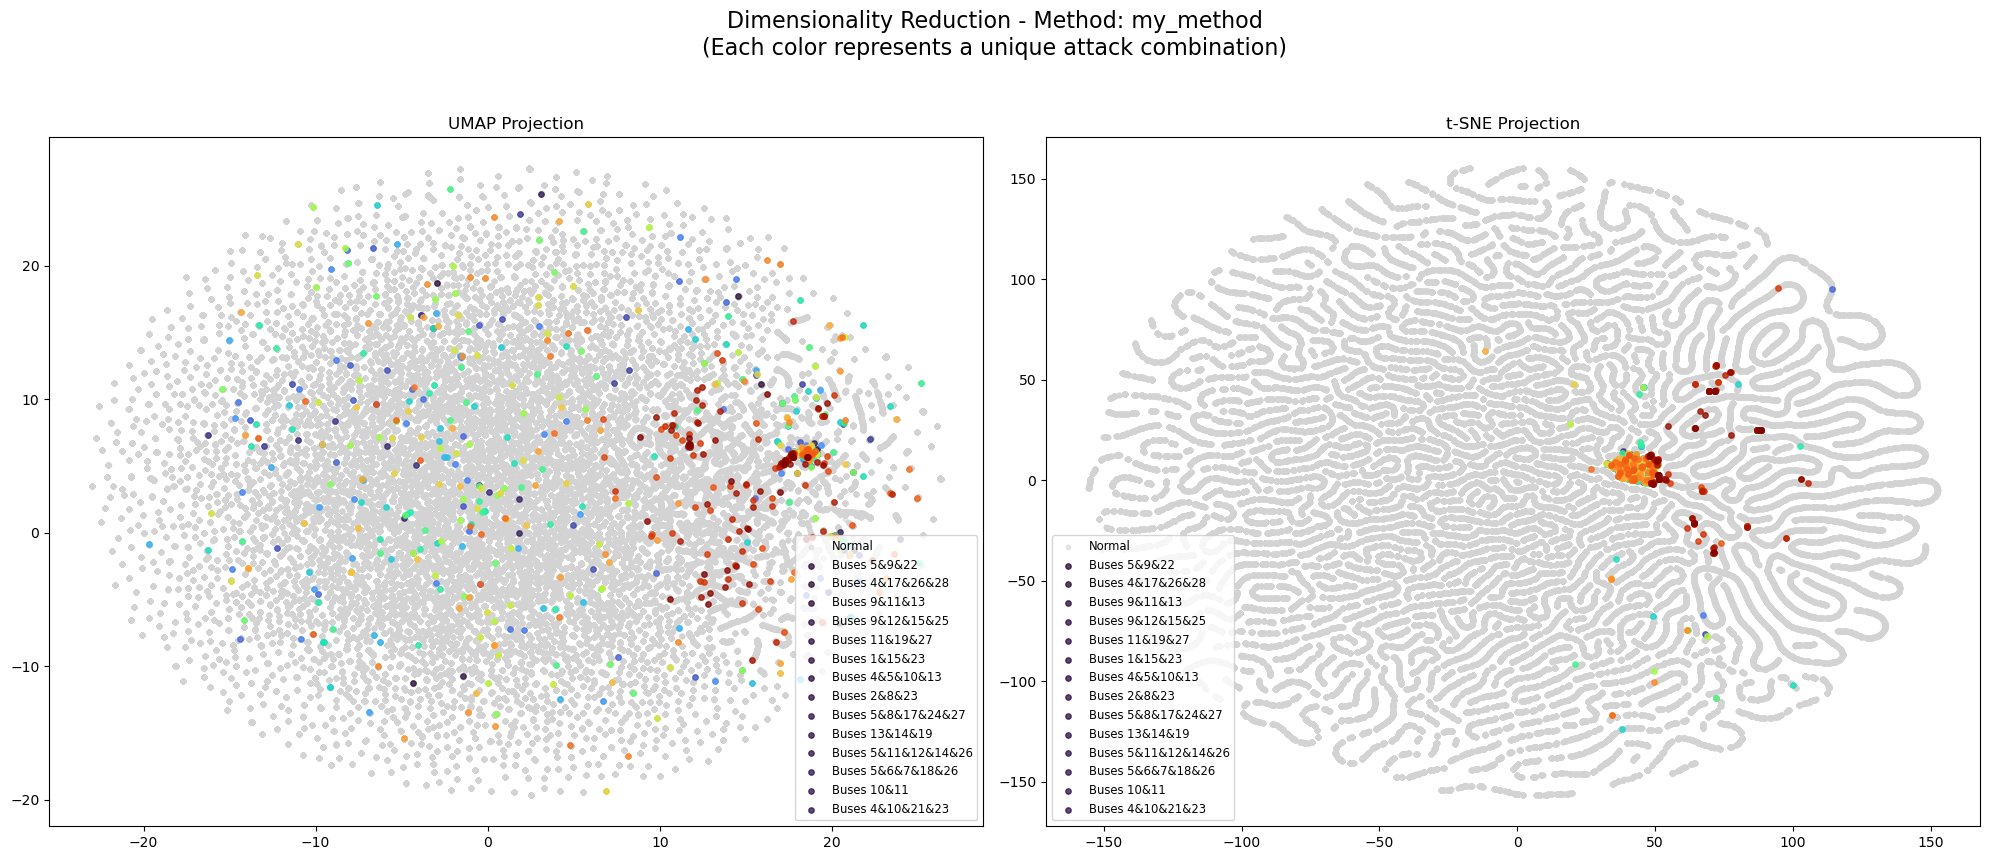


--- Silhouette Scores ---
Calculating Silhouette for 930 unique 1D labels on full X_scaled (153488 samples).
Silhouette on X_scaled will use sample_size=20000
Silhouette Score (on X_scaled, 1D labels, potentially sampled): -0.5711
Silhouette Score (on UMAP reduced data): -0.9347
Silhouette Score (on t-SNE reduced data): -0.6273

--- Second batch of 5 samples from X (all timesteps, all features) ---
Shape of the second batch of X: (5, 16, 41)

--- Window 5 from X (second batch) ---
  Shape: (16, 41)
  First 3 timesteps, first 5 features of window 5:
[[-0.49659664 -0.49076914 -0.49364026 -0.49812244 -0.49474361]
 [-0.49693585 -0.49160139 -0.49424099 -0.49831491 -0.49524984]
 [-0.52589487 -0.56265307 -0.54552716 -0.51474724 -0.53846807]]

--- Window 6 from X (second batch) ---
  Shape: (16, 41)
  First 3 timesteps, first 5 features of window 6:
[[-0.5379978  -0.59234793 -0.56696136 -0.52161486 -0.5565304 ]
 [-0.48403306 -0.45994409 -0.47139027 -0.49099344 -0.47599381]
 [-0.51718779 -0.54

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap
from sklearn.preprocessing import StandardScaler
import os
from sklearn.metrics import silhouette_score

# --- Configuration remains the same ---
method = "my_method"
config = DataConfig(
    main_data=data,
    method_name=method,
    norm=Norm.STANDARD, 
    timestep=16,
    verbose=True,
    random_seed=42,
    min_attacks=2,
    max_attacks=5,
    Ta=1000,
    c_min=0,
    c_max=1
)

config.print() 
X, y_multi_hot,_ = config.retrieve_data_set()

print("\n--- Initial Shapes & Sample Counts ---")

print("\n--- Dimensionality Reduction & Plotting ---")
if not (hasattr(X, 'size') and X.size > 0 and hasattr(y_multi_hot, 'size') and y_multi_hot.size > 0):
    print("❌ X or y_multi_hot is empty. Cannot proceed.")
else:

    X_flat_for_reduction = X.reshape(-1, X.shape[-1])
    y_for_analysis = y_multi_hot.reshape(-1, y_multi_hot.shape[-1])
    attack_samples_mask = np.any(y_for_analysis == 1, axis=1)

    attack_combination_map = {}
    next_attack_id = 1  

    y_plot_labels_1d = np.zeros(y_for_analysis.shape[0], dtype=int)

    attacked_indices_for_plot = np.where(attack_samples_mask)[0]
    for i in attacked_indices_for_plot:
        attack_combination = tuple(np.where(y_for_analysis[i] == 1)[0])
        
        if attack_combination not in attack_combination_map:
            attack_combination_map[attack_combination] = next_attack_id
            next_attack_id += 1
            
        y_plot_labels_1d[i] = attack_combination_map[attack_combination]

    id_to_string_map = {0: "Normal"}
    for combo, an_id in attack_combination_map.items():
        combo_str = "&".join(map(str, (c + 1 for c in combo)))
        id_to_string_map[an_id] = f"Buses {combo_str}"

    print(f"Generated {len(attack_combination_map)} unique attack combination labels for plotting.")
    
    
    scaler_dim_red = StandardScaler()
    X_scaled_for_reduction = scaler_dim_red.fit_transform(X_flat_for_reduction)

    umap_instance = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42, n_jobs=-1)
    print("Running UMAP...")
    umap_proj = umap_instance.fit_transform(X_scaled_for_reduction)
    print("UMAP completed.")

    tsne_instance = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1, init='pca', learning_rate='auto')
    print("Running t-SNE...")
    tsne_proj = tsne_instance.fit_transform(X_scaled_for_reduction)
    print("t-SNE completed.")

    fig, axs = plt.subplots(1, 2, figsize=(20, 9))
    fig.suptitle(f'Dimensionality Reduction - Method: {method}\n(Each color represents a unique attack combination)', fontsize=16)

    unique_labels_plot = np.unique(y_plot_labels_1d)
    
    colors_map_plot = plt.cm.get_cmap('turbo', len(unique_labels_plot))

    ax = axs[0]
    # Plot normal points first
    normal_indices_plot = (y_plot_labels_1d == 0)
    ax.scatter(umap_proj[normal_indices_plot, 0], umap_proj[normal_indices_plot, 1],
               color='lightgrey', alpha=0.5, label='Normal', s=10)

    plotted_legend_items_count = 1
    for label_id, combo_str in id_to_string_map.items():
        if label_id == 0: continue # Skip normal, already plotted
        
        idx_scatter = (y_plot_labels_1d == label_id)
        if np.any(idx_scatter):
            color = colors_map_plot(label_id / len(unique_labels_plot))
            # Limit the number of items in the legend for readability
            if plotted_legend_items_count < 15:
                ax.scatter(umap_proj[idx_scatter, 0], umap_proj[idx_scatter, 1], color=color, alpha=0.8, label=combo_str, s=15)
                plotted_legend_items_count += 1
            else:
                ax.scatter(umap_proj[idx_scatter, 0], umap_proj[idx_scatter, 1], color=color, alpha=0.8, s=15)
                
    ax.set_title('UMAP Projection')
    ax.legend(fontsize='small', loc='best')

    # t-SNE plot
    ax = axs[1]
    ax.scatter(tsne_proj[normal_indices_plot, 0], tsne_proj[normal_indices_plot, 1],
               color='lightgrey', alpha=0.5, label='Normal', s=10)
    
    plotted_legend_items_count = 1
    for label_id, combo_str in id_to_string_map.items():
        if label_id == 0: continue
            
        idx_scatter = (y_plot_labels_1d == label_id)
        if np.any(idx_scatter):
            color = colors_map_plot(label_id / len(unique_labels_plot))
            if plotted_legend_items_count < 15:
                ax.scatter(tsne_proj[idx_scatter, 0], tsne_proj[idx_scatter, 1], color=color, alpha=0.8, label=combo_str, s=15)
                plotted_legend_items_count += 1
            else:
                ax.scatter(tsne_proj[idx_scatter, 0], tsne_proj[idx_scatter, 1], color=color, alpha=0.8, s=15)

    ax.set_title('t-SNE Projection')
    ax.legend(fontsize='small', loc='best')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

print("\n--- Silhouette Scores ---")
if 'X_scaled_for_reduction' in locals() and X_scaled_for_reduction.ndim == 2 and X_scaled_for_reduction.shape[0] > 1 and \
   'y_plot_labels_1d' in locals() and y_plot_labels_1d.size == X_scaled_for_reduction.shape[0]:

    unique_labels_for_sil = np.unique(y_plot_labels_1d)
    num_unique_labels_sil = len(unique_labels_for_sil)

    if num_unique_labels_sil > 1 and num_unique_labels_sil < X_scaled_for_reduction.shape[0]:
        print(f"Calculating Silhouette for {num_unique_labels_sil} unique 1D labels on full X_scaled ({X_scaled_for_reduction.shape[0]} samples).")
       
        SIL_SAMPLE_SIZE_CONFIG = 20000 
        current_sil_sample_size_param = None
        if X_scaled_for_reduction.shape[0] > SIL_SAMPLE_SIZE_CONFIG * 1.2: 
            current_sil_sample_size_param = SIL_SAMPLE_SIZE_CONFIG
            print(f"Silhouette on X_scaled will use sample_size={current_sil_sample_size_param}")

        try:
            sil_score_original = silhouette_score(X_scaled_for_reduction, y_plot_labels_1d,
                                                  sample_size=current_sil_sample_size_param,
                                                  random_state=config.random_seed if hasattr(config, 'random_seed') else None)
            print(f"Silhouette Score (on X_scaled, 1D labels, potentially sampled): {sil_score_original:.4f}")
        except Exception as e_sil_orig:
            print(f"⚠️ Could not calculate Silhouette on X_scaled: {e_sil_orig}")
    else:
        print(f"Skipping Silhouette for X_scaled: Not enough unique labels ({num_unique_labels_sil}) or samples ({X_scaled_for_reduction.shape[0]}).")

    if umap_proj.ndim == 2 and umap_proj.shape[0] == y_plot_labels_1d.shape[0]:
        if num_unique_labels_sil > 1 and num_unique_labels_sil < umap_proj.shape[0]:
            try:
                sil_umap = silhouette_score(umap_proj, y_plot_labels_1d) 
                print(f"Silhouette Score (on UMAP reduced data): {sil_umap:.4f}")
            except Exception as e_sil_umap:
                print(f"⚠️ Could not calculate Silhouette on UMAP data: {e_sil_umap}")
        else:
            print("Skipping Silhouette for UMAP data: Not enough unique labels or samples.")

    if tsne_proj.ndim == 2 and tsne_proj.shape[0] == y_plot_labels_1d.shape[0]:
         if num_unique_labels_sil > 1 and num_unique_labels_sil < tsne_proj.shape[0]:
            try:
                sil_tsne = silhouette_score(tsne_proj, y_plot_labels_1d)
                print(f"Silhouette Score (on t-SNE reduced data): {sil_tsne:.4f}")
            except Exception as e_sil_tsne:
                print(f"⚠️ Could not calculate Silhouette on t-SNE data: {e_sil_tsne}")
         else:
            print("Skipping Silhouette for t-SNE data: Not enough unique labels or samples.")

else:
    print("⚠️ Prerequisites for Silhouette Score calculation not met (X_scaled_for_reduction or y_plot_labels_1d invalid).")
    if 'X_scaled_for_reduction' in locals() and hasattr(X_scaled_for_reduction, 'ndim'): print(f"    X_scaled_for_reduction shape: {X_scaled_for_reduction.shape if X_scaled_for_reduction.ndim > 0 else 'empty/invalid'}")
    if 'y_plot_labels_1d' in locals() and hasattr(y_plot_labels_1d, 'size'): print(f"    y_plot_labels_1d size: {y_plot_labels_1d.size}, unique labels: {len(np.unique(y_plot_labels_1d)) if y_plot_labels_1d.size > 0 else 'N/A'}")


if X.shape[0] >= 10: 
    print("\n--- Second batch of 5 samples from X (all timesteps, all features) ---")
    second_batch_X = X[5:10, :, :] if X.ndim ==3 else X[5:10, :] 
    print(f"Shape of the second batch of X: {second_batch_X.shape}")

    for i in range(second_batch_X.shape[0]): 
        window_original_index = 5 + i
        current_window_X = second_batch_X[i]
        print(f"\n--- Window {window_original_index} from X (second batch) ---")
        print(f"  Shape: {current_window_X.shape}")

        if current_window_X.ndim == 2 and current_window_X.shape[0]>=3 and current_window_X.shape[1]>=5 :
            print(f"  First 3 timesteps, first 5 features of window {window_original_index}:")
            print(current_window_X[:3, :5])
        elif current_window_X.ndim == 1 and current_window_X.shape[0] >=5: # اگر X دو بعدی بوده (و X_flat نمایش داده می‌شود)
             print(f"  First 5 features of sample {window_original_index}:")
             print(current_window_X[:5])
        else:
            print(f"  Sample data (or part of it) for window/sample {window_original_index}:")
            print(current_window_X) 
else:
    print(f"\nCannot display second batch of 5 for X, as X has only {X.shape[0]} samples (windows).")

if y_multi_hot.shape[0] >= 10:
    print("\n--- Second batch of 5 samples from y_multi_hot (all timesteps, all buses) ---")
    second_batch_y = y_multi_hot[5:10, :, :] 
    print(f"Shape of the second batch of y_multi_hot: {second_batch_y.shape}")

    for i in range(second_batch_y.shape[0]):
        window_original_index = 5 + i
        current_window_y = second_batch_y[i]
        print(f"\n--- Labels for Window {window_original_index} from y_multi_hot (second batch) ---")
        print(f"  Shape: {current_window_y.shape}")

        if current_window_y.shape[0]>=3 and current_window_y.shape[1]>=5:
            print(f"  First 3 timesteps, first 5 buses of window {window_original_index}:")
            print(current_window_y[:3, :5])
        else:
            print(f"  Label data (or part of it) for window {window_original_index}:")
            print(current_window_y)


        if np.any(current_window_y): 
            print(f"  Attacks found in window {window_original_index}.")

            for ts_idx in range(current_window_y.shape[0]): 
                if np.any(current_window_y[ts_idx, :]):
                    attacked_buses_in_ts = np.where(current_window_y[ts_idx, :] == 1)[0]
                    print(f"    Timestep {ts_idx}: Attacked buses (0-indexed): {attacked_buses_in_ts}")
        else:
            print(f"  No attacks found in window {window_original_index}.")
else:
    print(f"\nCannot display second batch of 5 for y_multi_hot, as y_multi_hot has only {y_multi_hot.shape[0]} samples (windows).")

In [6]:
import numpy as np
import os


if X.ndim == 3:
    X_to_save = X.reshape(-1, X.shape[-1])
elif X.ndim == 2:
    X_to_save = X
else:
    print("X array has an unexpected number of dimensions. Please check.")
    X_to_save = None # Or handle the error differently

if y_multi_hot.ndim == 3:
    y_to_save = y_multi_hot.reshape(-1, y_multi_hot.shape[-1])
elif y_multi_hot.ndim == 2:
    y_to_save = y_multi_hot
else:
    print("y_multi_hot array has an unexpected number of dimensions. Please check.")
    y_to_save = None # Or handle the error differently



output_csv_directory = "saved_csv_data2"
os.makedirs(output_csv_directory, exist_ok=True) 

x_csv_filename = os.path.join(output_csv_directory, "X_data6.csv")
y_csv_filename = os.path.join(output_csv_directory, "y_data6.csv")

if X_to_save is not None:
    print(f"Saving X array with shape {X_to_save.shape} to file: {x_csv_filename}")
    np.savetxt(x_csv_filename, X_to_save, delimiter=",", fmt='%1.8f')
    print("X array successfully saved to CSV file.")
else:
    print("X_to_save was not properly prepared. Skipping saving X.")

if y_to_save is not None:
    print(f"Saving y array with shape {y_to_save.shape} to file: {y_csv_filename}")
    np.savetxt(y_csv_filename, y_to_save, delimiter=",", fmt='%d')
    print("y array successfully saved to CSV file.")
else:
    print("y_to_save was not properly prepared. Skipping saving y.")

Saving X array with shape (153488, 41) to file: saved_csv_data2\X_data6.csv
X array successfully saved to CSV file.
Saving y array with shape (153488, 29) to file: saved_csv_data2\y_data6.csv
y array successfully saved to CSV file.


In [7]:
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


print("### 1. Loading initial dataset from CSV files... ###")

output_csv_directory = "saved_csv_data2"
x_csv_filename = os.path.join(output_csv_directory, "X_data6.csv")
y_csv_filename = os.path.join(output_csv_directory, "y_data6.csv")

try:
    X_full_data = np.loadtxt(x_csv_filename, delimiter=",")
    y_full_data = np.loadtxt(y_csv_filename, delimiter=",", dtype=int)
    print("✅ Initial data loaded from CSV successfully.")
    print(f"Initial X shape: {X_full_data.shape}")
    print(f"Initial y shape: {y_full_data.shape}")
except FileNotFoundError:
    print(f"❌ Error: Could not find data files in '{output_csv_directory}'. Please ensure the previous notebook cell was run successfully.")
    # Exit or handle the error appropriately
    X_full_data, y_full_data = (None, None)

print("-" * 50)


if X_full_data is not None:
    # ==============================================================================
    # Stage 2: Split data and Normalize
    # ==============================================================================
    print("### 2. Splitting data and Scaling... ###")

    # Create a key for stratified splitting
    y_stratify = np.any(y_full_data, axis=1).astype(int)

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X_full_data,
        y_full_data,
        test_size=0.2,
        random_state=42,
        stratify=y_stratify
    )

    # Scale the data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print("✅ Data splitting and scaling complete.")
    print("-" * 50)

    print("### 3. Applying Undersampling and Saving final datasets... ###")
    
    has_attack_mask = np.any(y_train == 1, axis=1)
    indices_with_attacks = np.where(has_attack_mask)[0]
    indices_no_attacks = np.where(~has_attack_mask)[0]

    num_with_attacks = len(indices_with_attacks)
    num_no_attacks_original = len(indices_no_attacks)

    print(f"Training samples with at least one attack: {num_with_attacks}")
    print(f"Training samples with no attacks (before undersampling): {num_no_attacks_original}")

    final_indices_no_attacks = indices_no_attacks
    if num_with_attacks > 0 and num_no_attacks_original > num_with_attacks:
        ratio = 2 # Your desired ratio
        desired_no_attack_samples = int(num_with_attacks * ratio)
        print(f"Undersampling 'no attack' samples from {num_no_attacks_original} to {desired_no_attack_samples}")
        np.random.seed(42)
        final_indices_no_attacks = np.random.choice(indices_no_attacks, size=desired_no_attack_samples, replace=False)

    # Combine and shuffle the final indices
    final_indices_train = np.concatenate([indices_with_attacks, final_indices_no_attacks])
    np.random.seed(42)
    np.random.shuffle(final_indices_train)

    # Create final training sets
    X_train_unscaled_final = X_train[final_indices_train]
    X_train_scaled_final = X_train_scaled[final_indices_train]
    y_train_final = y_train[final_indices_train]

    print(f"Final shape after processing: X_train: {X_train_unscaled_final.shape}, y_train: {y_train_final.shape}")
    print("-" * 50)

    output_dir = "final_processed_data"
    os.makedirs(output_dir, exist_ok=True)

    np.save(os.path.join(output_dir, 'X_train_scaled6.npy'), X_train_scaled_final)
    np.save(os.path.join(output_dir, 'y_train_scaled6.npy'), y_train_final)
    np.save(os.path.join(output_dir, 'X_test_scaled6.npy'), X_test_scaled)
    print("✅ Scaled data saved successfully.")

    np.save(os.path.join(output_dir, 'X_train_unscaled6.npy'), X_train_unscaled_final)
    np.save(os.path.join(output_dir, 'y_train_unscaled6.npy'), y_train_final)
    np.save(os.path.join(output_dir, 'X_test_unscaled6.npy'), X_test)
    print("✅ Unscaled data saved successfully.")

    np.save(os.path.join(output_dir, 'y_test6.npy'), y_test)
    print(f"All final .npy data saved in '{output_dir}' directory.")

### 1. Loading initial dataset from CSV files... ###
✅ Initial data loaded from CSV successfully.
Initial X shape: (153488, 41)
Initial y shape: (153488, 29)
--------------------------------------------------
### 2. Splitting data and Scaling... ###
✅ Data splitting and scaling complete.
--------------------------------------------------
### 3. Applying Undersampling and Saving final datasets... ###
Training samples with at least one attack: 800
Training samples with no attacks (before undersampling): 121990
Undersampling 'no attack' samples from 121990 to 1600
Final shape after processing: X_train: (2400, 41), y_train: (2400, 29)
--------------------------------------------------
✅ Scaled data saved successfully.
✅ Unscaled data saved successfully.
All final .npy data saved in 'final_processed_data' directory.


In [8]:

print("--- Starting Unified Data Preparation (3D Only) ---")

# --- All Imports at the Top ---
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


print("\n--- 1. Loading and Reshaping Initial Data ---")
try:
    # These variables should be in memory from the previous cell
    assert 'X_to_save' in locals() and 'y_to_save' in locals()

    # Define time series parameters
    timesteps = 16
    n_features_X = X_to_save.shape[1]
    n_buses = y_to_save.shape[1]
    num_windows = X_to_save.shape[0] // timesteps

    # Create 3D time-windowed data (for LSTM-based models)
    X_3d_full = X_to_save[:num_windows * timesteps].reshape(num_windows, timesteps, n_features_X)
    y_3d_reshaped = y_to_save[:num_windows * timesteps].reshape(num_windows, timesteps, n_buses)
    
    # Create one label set per window by checking for any attack within the window
    y_windowed_full = np.any(y_3d_reshaped, axis=1).astype(int)

    print(f"Reshaped data into {num_windows} windows of size ({timesteps}, {n_features_X}).")

except Exception as e:
    print(f"ERROR: Could not find or reshape initial data. Ensure the data generation cell was run. Details: {e}")
    raise e


print("\n--- 2. Performing Consistent Train-Test Split ---")

indices = np.arange(num_windows)
y_stratify = np.any(y_windowed_full, axis=1)

train_indices, test_indices = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=y_stratify
)

# --- Create the primary 3D train/test sets ---
X_train_3d = X_3d_full[train_indices]
X_test_3d = X_3d_full[test_indices]
y_train_windowed = y_windowed_full[train_indices]
y_test_windowed = y_windowed_full[test_indices]

print(f"Split data into {len(train_indices)} training windows and {len(test_indices)} testing windows.")


print("\n--- 3. Scaling 3D Data ---")

# Reshape to 2D temporarily for the scaler
X_train_2d_temp = X_train_3d.reshape(-1, n_features_X)
X_test_2d_temp = X_test_3d.reshape(-1, n_features_X)

# Fit scaler ONLY on training data
scaler = StandardScaler().fit(X_train_2d_temp)

# Transform and reshape back to 3D
X_train_3d_scaled = scaler.transform(X_train_2d_temp).reshape(X_train_3d.shape)
X_test_3d_scaled = scaler.transform(X_test_2d_temp).reshape(X_test_3d.shape)

print("Created scaled 3D versions of the data.")

print("\n--- 4. Undersampling Training Data and Saving 3D Files ---")

has_attack_mask_train = np.any(y_train_windowed == 1, axis=1)
attack_indices = np.where(has_attack_mask_train)[0]
no_attack_indices = np.where(~has_attack_mask_train)[0]

ratio = 2 
num_no_attack_samples = min(len(no_attack_indices), int(len(attack_indices) * ratio))
np.random.seed(42)
selected_no_attack_indices = np.random.choice(no_attack_indices, size=num_no_attack_samples, replace=False)

final_train_indices = np.concatenate([attack_indices, selected_no_attack_indices])
np.random.shuffle(final_train_indices)

print(f"Undersampled training set from {len(y_train_windowed)} to {len(final_train_indices)} windows.")

X_train_3d_final_scaled = X_train_3d_scaled[final_train_indices]
y_train_windowed_final = y_train_windowed[final_train_indices]

output_dir = "final_processed_data"
os.makedirs(output_dir, exist_ok=True)

# Save data for 3D models (LSTM, etc.)
np.save(os.path.join(output_dir, 'X_train_3d_scaled6.npy'), X_train_3d_final_scaled)
np.save(os.path.join(output_dir, 'y_train_windowed6.npy'), y_train_windowed_final)
np.save(os.path.join(output_dir, 'X_test_3d_scaled6.npy'), X_test_3d_scaled)
np.save(os.path.join(output_dir, 'y_test_windowed6.npy'), y_test_windowed)
print("✅ Saved datasets for 3D models.")

print(f"\nAll final datasets saved in '{output_dir}' directory.")


--- Starting Unified Data Preparation (3D Only) ---

--- 1. Loading and Reshaping Initial Data ---
Reshaped data into 9593 windows of size (16, 41).

--- 2. Performing Consistent Train-Test Split ---
Split data into 7674 training windows and 1919 testing windows.

--- 3. Scaling 3D Data ---
Created scaled 3D versions of the data.

--- 4. Undersampling Training Data and Saving 3D Files ---
Undersampled training set from 7674 to 2307 windows.
✅ Saved datasets for 3D models.

All final datasets saved in 'final_processed_data' directory.


C:\Users\Green\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Green\AppData\Local\Temp\ipykernel_4776\930048317.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', num_colors)


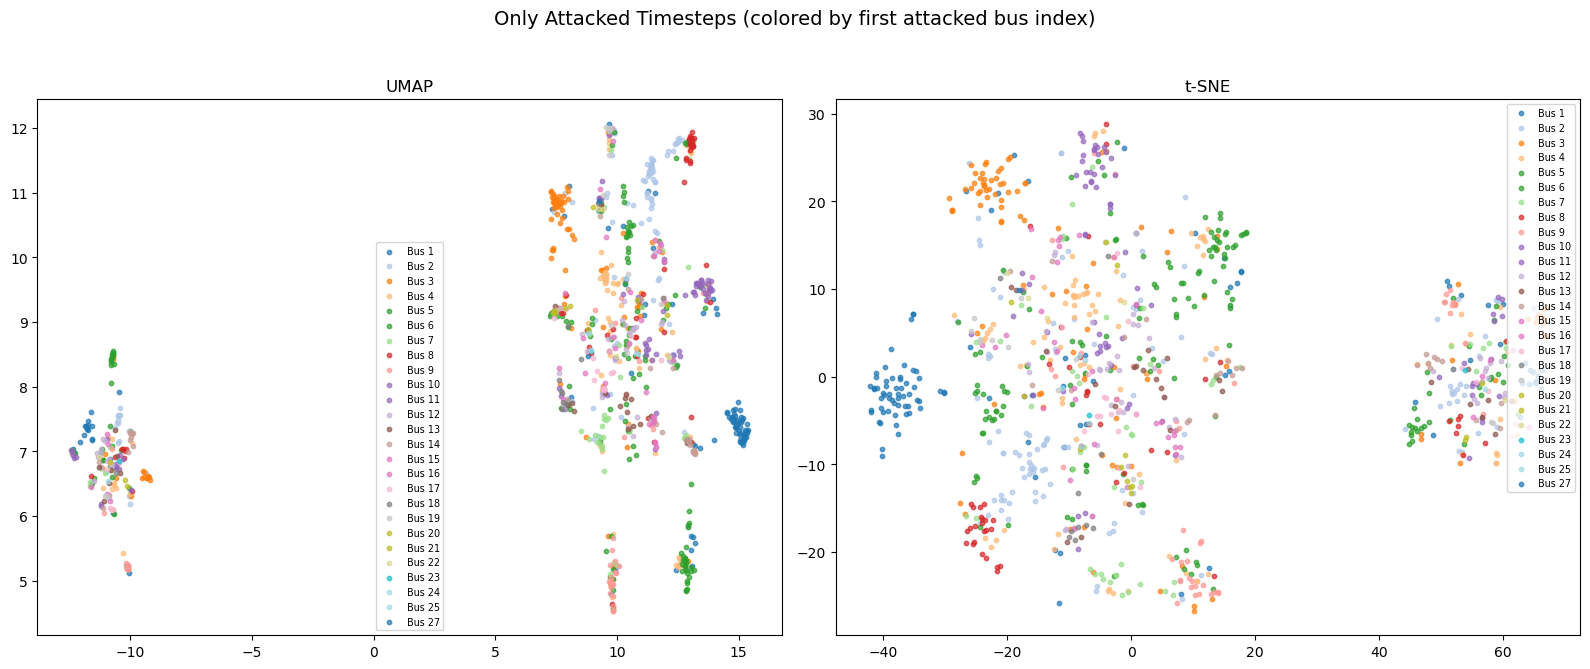

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap
from sklearn.preprocessing import StandardScaler

X_flat = X.reshape(-1, X.shape[2])
y_flat = y_multi_hot.reshape(-1, y_multi_hot.shape[2])

attacked_indices = np.any(y_flat == 1, axis=1)
X_attacked = X_flat[attacked_indices]
y_attacked = y_flat[attacked_indices]

y_labels_1d = np.array([np.where(y == 1)[0][0] + 1 for y in y_attacked])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_attacked)

umap_proj = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_scaled)
tsne_proj = TSNE(n_components=2, perplexity=30, random_state=42, init='pca').fit_transform(X_scaled)

fig, axs = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Only Attacked Timesteps (colored by first attacked bus index)", fontsize=14)

unique_labels = np.unique(y_labels_1d)
num_colors = min(len(unique_labels), 30)
cmap = plt.cm.get_cmap('tab20', num_colors)

axs[0].set_title("UMAP")
for lbl in unique_labels:
    mask = y_labels_1d == lbl
    axs[0].scatter(umap_proj[mask, 0], umap_proj[mask, 1], label=f"Bus {lbl}", s=10, alpha=0.7, color=cmap(lbl % num_colors))
axs[0].legend(fontsize='x-small', loc='best')

axs[1].set_title("t-SNE")
for lbl in unique_labels:
    mask = y_labels_1d == lbl
    axs[1].scatter(tsne_proj[mask, 0], tsne_proj[mask, 1], label=f"Bus {lbl}", s=10, alpha=0.7, color=cmap(lbl % num_colors))
axs[1].legend(fontsize='x-small', loc='best')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap
from sklearn.preprocessing import StandardScaler

print("Starting automatic processing of 5 scenarios for IEEE DataPort...")

scenarios = {
    1: {"name": "Scenario_1_High_Intensity", "c_min": 0, "c_max": 1, "min_atk": 2, "max_atk": 5},
    2: {"name": "Scenario_2_Medium_Intensity", "c_min": 0.1, "c_max": 0.2, "min_atk": 2, "max_atk": 5},
    3: {"name": "Scenario_3_High_Stealth", "c_min": 0.01, "c_max": 0.1, "min_atk": 2, "max_atk": 5},
    4: {"name": "Scenario_4_Combined_Attacks", "c_min": 0.01, "c_max": 0.1, "min_atk": 2, "max_atk": 8},
    5: {"name": "Scenario_5_Advanced_Combined", "c_min": 0.005, "c_max": 0.05, "min_atk": 2, "max_atk": 8}
}

base_output_dir = "FDIA_IEEE30_MultiScenario_Dataset"
os.makedirs(base_output_dir, exist_ok=True)

for s_id, params in scenarios.items():
    s_name = params["name"]
    print(f"\n{'='*50}\nProcessing: {s_name} ...\n{'='*50}")

    scenario_dir = os.path.join(base_output_dir, s_name)
    os.makedirs(scenario_dir, exist_ok=True)

    config = DataConfig(
        main_data=data,
        method_name="my_method",
        norm=Norm.STANDARD,
        timestep=16,
        verbose=False,
        random_seed=42,
        min_attacks=params["min_atk"],
        max_attacks=params["max_atk"],
        Ta=1000,
        c_min=params["c_min"],
        c_max=params["c_max"]
    )
    
    X, y_multi_hot, _ = config.retrieve_data_set()
    if X.size == 0 or y_multi_hot.size == 0:
        print(f"Error generating data for {s_name}")
        continue

    X_flat = X.reshape(-1, X.shape[2])
    y_flat = y_multi_hot.reshape(-1, y_multi_hot.shape[2])
    attacked_indices_mask = np.any(y_flat == 1, axis=1)

    print(f"Saving 2D CSV files for {s_name}...")
    x_headers = [f'P_Branch_{i+1}' for i in range(X_flat.shape[1])]
    df_x = pd.DataFrame(X_flat, columns=x_headers)
    x_csv_path = os.path.join(scenario_dir, f"X_data_Standard_S{s_id}.csv")
    df_x.to_csv(x_csv_path, index=False)

    y_headers = [f'Bus_{i+1}_Attack_Label' for i in range(y_flat.shape[1])]
    df_y = pd.DataFrame(y_flat, columns=y_headers)
    y_csv_path = os.path.join(scenario_dir, f"y_data_Standard_S{s_id}.csv")
    df_y.to_csv(y_csv_path, index=False)

    if s_id == 1:
        print("\nPreview of first 5 rows for X (Active Power Measurements) in Scenario 1:")
        print(df_x.head())
        print("\nPreview of first 5 rows for y (Localization Labels) in Scenario 1:")
        print(df_y.head())
        print("-" * 50)

    print(f"Generating UMAP/t-SNE plots for {s_name}...")
    
    X_attacked = X_flat[attacked_indices_mask]
    y_attacked = y_flat[attacked_indices_mask]
    
    if len(X_attacked) > 0:
        y_labels_1d_attacked = np.array([np.where(y == 1)[0][0] + 1 for y in y_attacked])
        scaler_atk = StandardScaler()
        X_scaled_attacked = scaler_atk.fit_transform(X_attacked)

        umap_proj_atk = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_scaled_attacked)
        tsne_proj_atk = TSNE(n_components=2, perplexity=30, random_state=42, init='pca').fit_transform(X_scaled_attacked)

        fig, axs = plt.subplots(1, 2, figsize=(16, 7))
        fig.suptitle(f"{s_name} - Attacked Timesteps Only", fontsize=14)

        unique_labels_atk = np.unique(y_labels_1d_attacked)
        num_colors_atk = min(len(unique_labels_atk), 30)
        try:
            cmap_atk = plt.get_cmap('tab20', num_colors_atk)
        except AttributeError:
            cmap_atk = plt.cm.get_cmap('tab20', num_colors_atk)

        axs[0].set_title("UMAP")
        axs[1].set_title("t-SNE")

        for lbl in unique_labels_atk:
            mask = y_labels_1d_attacked == lbl
            c = cmap_atk(lbl % num_colors_atk)
            axs[0].scatter(umap_proj_atk[mask, 0], umap_proj_atk[mask, 1], label=f"Bus {lbl}", s=10, alpha=0.7, color=c)
            axs[1].scatter(tsne_proj_atk[mask, 0], tsne_proj_atk[mask, 1], label=f"Bus {lbl}", s=10, alpha=0.7, color=c)

        axs[0].legend(fontsize='x-small', loc='best')
        axs[1].legend(fontsize='x-small', loc='best')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])

        plot_path_atk = os.path.join(scenario_dir, f"TSNE_UMAP_Attacked_S{s_id}.png")
        plt.savefig(plot_path_atk, dpi=300, bbox_inches='tight')
        plt.close(fig)
        print(f"Saved attacked-only plot: {plot_path_atk}")

    y_plot_labels_1d = np.zeros(y_flat.shape[0], dtype=int)
    attack_combination_map = {}
    next_attack_id = 1

    for i in np.where(attacked_indices_mask)[0]:
        combo = tuple(np.where(y_flat[i] == 1)[0])
        if combo not in attack_combination_map:
            attack_combination_map[combo] = next_attack_id
            next_attack_id += 1
        y_plot_labels_1d[i] = attack_combination_map[combo]

    scaler_full = StandardScaler()
    X_scaled_full = scaler_full.fit_transform(X_flat)

    umap_proj_full = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(X_scaled_full)
    tsne_proj_full = TSNE(n_components=2, perplexity=30, random_state=42, init='pca').fit_transform(X_scaled_full)

    fig, axs = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(f"{s_name} - Full Data (Normal vs Attacks)", fontsize=14)

    unique_labels = np.unique(y_plot_labels_1d)
    num_colors = min(len(unique_labels), 30)
    try:
        cmap = plt.get_cmap('turbo', num_colors)
    except AttributeError:
        cmap = plt.cm.get_cmap('turbo', num_colors)

    axs[0].set_title("UMAP")
    axs[1].set_title("t-SNE")

    normal_mask = (y_plot_labels_1d == 0)
    axs[0].scatter(umap_proj_full[normal_mask, 0], umap_proj_full[normal_mask, 1], color='lightgrey', alpha=0.3, label='Normal', s=5)
    axs[1].scatter(tsne_proj_full[normal_mask, 0], tsne_proj_full[normal_mask, 1], color='lightgrey', alpha=0.3, label='Normal', s=5)

    plotted_legend_items = 1
    for lbl in unique_labels:
        if lbl == 0: continue
        mask = (y_plot_labels_1d == lbl)
        c = cmap(lbl / len(unique_labels))
        if plotted_legend_items < 15:
            axs[0].scatter(umap_proj_full[mask, 0], umap_proj_full[mask, 1], label=f"Attack Combo {lbl}", s=10, alpha=0.8, color=c)
            axs[1].scatter(tsne_proj_full[mask, 0], tsne_proj_full[mask, 1], label=f"Attack Combo {lbl}", s=10, alpha=0.8, color=c)
            plotted_legend_items += 1
        else:
            axs[0].scatter(umap_proj_full[mask, 0], umap_proj_full[mask, 1], s=10, alpha=0.8, color=c)
            axs[1].scatter(tsne_proj_full[mask, 0], tsne_proj_full[mask, 1], s=10, alpha=0.8, color=c)

    axs[0].legend(fontsize='x-small', loc='best')
    axs[1].legend(fontsize='x-small', loc='best')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    plot_path_full = os.path.join(scenario_dir, f"TSNE_UMAP_FullData_S{s_id}.png")
    plt.savefig(plot_path_full, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved full data plot: {plot_path_full}")

    print(f"Saving 3D NPY files for Deep Learning models...")
    np.save(os.path.join(scenario_dir, f"X_data_3D_S{s_id}.npy"), X)
    np.save(os.path.join(scenario_dir, f"y_data_3D_S{s_id}.npy"), y_multi_hot)

print("\nAll 5 scenarios processed and saved successfully in 'FDIA_IEEE30_MultiScenario_Dataset' folder.")

Starting automatic processing of 5 scenarios for IEEE DataPort...

Processing: Scenario_1_High_Intensity ...
Saving 2D CSV files for Scenario_1_High_Intensity...

Preview of first 5 rows for X (Active Power Measurements) in Scenario 1:
   P_Branch_1  P_Branch_2  P_Branch_3  P_Branch_4  P_Branch_5  P_Branch_6  \
0   -0.507611   -0.517792   -0.513146   -0.504372   -0.511181   -0.511011   
1   -0.518359   -0.544163   -0.532181   -0.510471   -0.527221   -0.526797   
2   -0.473999   -0.435325   -0.453620   -0.485300   -0.461019   -0.461648   
3   -0.498702   -0.495936   -0.497369   -0.499317   -0.497886   -0.497928   
4   -0.497464   -0.492898   -0.495177   -0.498615   -0.496038   -0.496110   

   P_Branch_7  P_Branch_8  P_Branch_9  P_Branch_10  ...  P_Branch_32  \
0   -0.507442   -0.511181   -0.512045    -0.511041  ...    -0.514913   
1   -0.517945   -0.527221   -0.529395    -0.526871  ...    -0.536694   
2   -0.474598   -0.461019   -0.457788    -0.461539  ...    -0.446800   
3   -0.498737

C:\Users\Green\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved attacked-only plot: FDIA_IEEE30_MultiScenario_Dataset\Scenario_1_High_Intensity\TSNE_UMAP_Attacked_S1.png


C:\Users\Green\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Green\anaconda3\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
C:\Users\Green\anaconda3\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
C:\Users\Green\anaconda3\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random 

Saved full data plot: FDIA_IEEE30_MultiScenario_Dataset\Scenario_1_High_Intensity\TSNE_UMAP_FullData_S1.png
Saving 3D NPY files for Deep Learning models...

Processing: Scenario_2_Medium_Intensity ...
Saving 2D CSV files for Scenario_2_Medium_Intensity...
Generating UMAP/t-SNE plots for Scenario_2_Medium_Intensity...


...

Saved full data plot: FDIA_IEEE30_MultiScenario_Dataset\Scenario_4_Combined_Attacks\TSNE_UMAP_FullData_S4.png
Saving 3D NPY files for Deep Learning models...

Processing: Scenario_5_Advanced_Combined ...
Saving 2D CSV files for Scenario_5_Advanced_Combined...
Generating UMAP/t-SNE plots for Scenario_5_Advanced_Combined...


C:\Users\Green\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved attacked-only plot: FDIA_IEEE30_MultiScenario_Dataset\Scenario_5_Advanced_Combined\TSNE_UMAP_Attacked_S5.png


C:\Users\Green\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\Green\anaconda3\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
C:\Users\Green\anaconda3\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
C:\Users\Green\anaconda3\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random 

Saved full data plot: FDIA_IEEE30_MultiScenario_Dataset\Scenario_5_Advanced_Combined\TSNE_UMAP_FullData_S5.png
Saving 3D NPY files for Deep Learning models...

All 5 scenarios processed and saved successfully in 'FDIA_IEEE30_MultiScenario_Dataset' folder.


In [26]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print(" Starting Train/Test data extraction and saving from existing CSVs \n")

scenarios = {
    1: "Scenario_1_High_Intensity",
    2: "Scenario_2_Medium_Intensity",
    3: "Scenario_3_High_Stealth",
    4: "Scenario_4_Combined_Attacks",
    5: "Scenario_5_Advanced_Combined"
}

base_dir = "FDIA_IEEE30_MultiScenario_Dataset"
timestep = 16

for s_id, s_name in scenarios.items():
    scenario_dir = os.path.join(base_dir, s_name)
    print(f"\n{'='*50}\n⏳ Processing Train/Test for: {s_name} ...\n{'='*50}")
    
    x_csv_path = os.path.join(scenario_dir, f"X_data_Standard_S{s_id}.csv")
    y_csv_path = os.path.join(scenario_dir, f"y_data_Standard_S{s_id}.csv")
    
    if not os.path.exists(x_csv_path) or not os.path.exists(y_csv_path):
        print(f"❌ CSV files for Scenario {s_id} not found! Skipping...")
        continue
        
    print(" Reading CSV files...")
    df_x = pd.read_csv(x_csv_path)
    df_y = pd.read_csv(y_csv_path)
    
    X_2d = df_x.values
    y_2d = df_y.values
    
    n_features = X_2d.shape[1]
    n_buses = y_2d.shape[1]
    num_windows = X_2d.shape[0] // timestep
    
    X_3d = X_2d[:num_windows * timestep].reshape(num_windows, timestep, n_features)
    y_3d = y_2d[:num_windows * timestep].reshape(num_windows, timestep, n_buses)
    
    y_windowed_full = np.any(y_3d, axis=1).astype(int)
    y_stratify = np.any(y_windowed_full, axis=1)
    
    print(" Performing Train/Test split...")
    indices = np.arange(num_windows)
    train_indices, test_indices = train_test_split(indices, test_size=0.2, random_state=42, stratify=y_stratify)
    
    X_train_3d = X_3d[train_indices]
    X_test_3d = X_3d[test_indices]
    y_train_windowed = y_windowed_full[train_indices]
    y_test_windowed = y_windowed_full[test_indices]
    
    print(" Scaling data...")
    X_train_2d_temp = X_train_3d.reshape(-1, n_features)
    X_test_2d_temp = X_test_3d.reshape(-1, n_features)
    
    scaler = StandardScaler().fit(X_train_2d_temp)
    X_train_3d_scaled = scaler.transform(X_train_2d_temp).reshape(X_train_3d.shape)
    X_test_3d_scaled = scaler.transform(X_test_2d_temp).reshape(X_test_3d.shape)
    
    print(" Balancing training data (Undersampling)...")
    has_attack_mask_train = np.any(y_train_windowed == 1, axis=1)
    attack_indices = np.where(has_attack_mask_train)[0]
    no_attack_indices = np.where(~has_attack_mask_train)[0]
    
    ratio = 2
    num_no_attack_samples = min(len(no_attack_indices), int(len(attack_indices) * ratio))
    np.random.seed(42)
    selected_no_attack_indices = np.random.choice(no_attack_indices, size=num_no_attack_samples, replace=False)
    
    final_train_indices = np.concatenate([attack_indices, selected_no_attack_indices])
    np.random.shuffle(final_train_indices)
    
    X_train_3d_final_scaled = X_train_3d_scaled[final_train_indices]
    y_train_windowed_final = y_train_windowed[final_train_indices]
    
    print(" Saving ML-Ready files (NPY format)...")
    np.save(os.path.join(scenario_dir, f'X_train_3d_scaled_S{s_id}.npy'), X_train_3d_final_scaled)
    np.save(os.path.join(scenario_dir, f'y_train_windowed_S{s_id}.npy'), y_train_windowed_final)
    np.save(os.path.join(scenario_dir, f'X_test_3d_scaled_S{s_id}.npy'), X_test_3d_scaled)
    np.save(os.path.join(scenario_dir, f'y_test_windowed_S{s_id}.npy'), y_test_windowed)
    
    print(f"✅ Train/Test files for Scenario {s_id} saved successfully.")

print("\n Done! All Train and Test data for 5 scenarios are generated and saved.")

 Starting Train/Test data extraction and saving from existing CSVs 


⏳ Processing Train/Test for: Scenario_1_High_Intensity ...
 Reading CSV files...
 Performing Train/Test split...
 Scaling data...
 Balancing training data (Undersampling)...
 Saving ML-Ready files (NPY format)...
✅ Train/Test files for Scenario 1 saved successfully.

⏳ Processing Train/Test for: Scenario_2_Medium_Intensity ...
 Reading CSV files...
 Performing Train/Test split...
 Scaling data...
 Balancing training data (Undersampling)...
 Saving ML-Ready files (NPY format)...
✅ Train/Test files for Scenario 2 saved successfully.

⏳ Processing Train/Test for: Scenario_3_High_Stealth ...
 Reading CSV files...
 Performing Train/Test split...
 Scaling data...
 Balancing training data (Undersampling)...
 Saving ML-Ready files (NPY format)...
✅ Train/Test files for Scenario 3 saved successfully.

⏳ Processing Train/Test for: Scenario_4_Combined_Attacks ...
 Reading CSV files...
 Performing Train/Test split...
 Scaling da